In [ ]:
import pandas as pd

catnat = pd.read_csv('bquxjob_42e98690_1a039e1fadd.csv')
geoloc = pd.read_csv('bquxjob_4fa9d324_1a039e56d2b.csv')

print(catnat.columns.tolist())
print(catnat.shape)
print()
print(geoloc.columns.tolist())
print(geoloc.shape)
geoloc.head()

FileNotFoundError: [Errno 2] No such file or directory: 'bquxjob_42e98690_1a039e1fadd.csv'

In [ ]:
import pandas as pd

# 1. Charger les données
catnat = pd.read_csv('bquxjob_42e98690_1a039e1fadd.csv')
geoloc = pd.read_csv('bquxjob_4fa9d324_1a039e56d2b.csv')

# 2. Aligner le format des codes commune (5 chiffres, zéros en tête)
catnat['code_commune'] = catnat['code_commune'].astype(str).str.zfill(5)
geoloc['code_commune_INSEE'] = geoloc['code_commune_INSEE'].astype(str).str.zfill(5)

# 3. Mapper les 13 codes de risque GASPAR vers les 7 catégories du site CCR
mapping_peril = {
    'ICB': 'Inondations', 'IRN': 'Inondations', 'RAZ': 'Inondations', 'CMV': 'Inondations',
    'SEC': 'Sécheresse',
    'GLT': 'Mouvement de terrain', 'ECB': 'Mouvement de terrain', 'MVT': 'Mouvement de terrain',
    'SEI': 'Séisme',
    'AVA': 'Avalanche',
    'TMP': 'Vent cyclonique',
    'GRL': 'Autres périls', 'PDN': 'Autres périls',
}
catnat['type_peril'] = catnat['num_risque_jo'].map(mapping_peril)

# 4. Compter le nb de reconnaissances par commune ET par péril
catnat_par_peril = (
    catnat.groupby(['code_commune', 'type_peril'])
    .size()
    .reset_index(name='nb_reconnaissances')
)

# 5. Ajouter la ligne "Tous périls" (tous types confondus)
tous_perils = (
    catnat.groupby('code_commune')
    .size()
    .reset_index(name='nb_reconnaissances')
)
tous_perils['type_peril'] = 'Tous périls'

catnat_final = pd.concat([catnat_par_peril, tous_perils], ignore_index=True)

# 6. Jointure avec la géolocalisation (ajoute lat/lon/nom_commune/département/région)
df_map = catnat_final.merge(
    geoloc,
    left_on='code_commune',
    right_on='code_commune_INSEE',
    how='left'
)

print(df_map.shape)
print(df_map.head(10))

# Communes de catnat sans correspondance géo (à vérifier si le nb est élevé)
sans_geoloc = df_map[df_map['latitude'].isna()]['code_commune'].nunique()
print(f"Communes catnat sans géoloc trouvée : {sans_geoloc}")

df_map.to_csv('catnat_geoloc_final.csv', index=False)

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import urllib.request
import json

# ============================================================
# 1. Charger les données déjà préparées (catnat + geoloc jointes)
# ============================================================
df_map = pd.read_csv('catnat_geoloc_final.csv', dtype={'code_commune': str})
df_map['code_commune'] = df_map['code_commune'].str.zfill(5)

# ============================================================
# 2. Télécharger le GeoJSON des contours de communes (une fois)
# ============================================================
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-version-simplifiee.geojson"
urllib.request.urlretrieve(geojson_url, "communes.geojson")

with open("communes.geojson") as f:
    communes_geojson = json.load(f)

# ============================================================
# 3. Définir les tranches de couleur façon CCR (≤5, 6-10, 11-15, 16-25, >25)
# ============================================================
def tranche(n):
    if n <= 5:
        return 0
    elif n <= 10:
        return 1
    elif n <= 15:
        return 2
    elif n <= 25:
        return 3
    else:
        return 4

couleurs = ['#f9d6c4', '#f2a684', '#e8794f', '#c9432b', '#7a1c11']
labels_tranches = ['≤ 5', '6 - 10', '11 - 15', '16 - 25', '> 25']

# ============================================================
# 4. Construire une trace par péril (Tous périls + les 7 catégories)
# ============================================================
perils = ['Tous périls', 'Inondations', 'Sécheresse', 'Mouvement de terrain',
          'Séisme', 'Avalanche', 'Vent cyclonique', 'Autres périls']

fig = go.Figure()

for i, peril in enumerate(perils):
    sub = df_map[df_map['type_peril'] == peril].copy()
    sub['tranche'] = sub['nb_reconnaissances'].apply(tranche)

    fig.add_trace(go.Choroplethmapbox(
        geojson=communes_geojson,
        locations=sub['code_commune'],
        z=sub['tranche'],
        featureidkey="properties.code",  # clé du GeoJSON à vérifier (souvent 'code' ou 'code_insee')
        colorscale=[[k/4, c] for k, c in enumerate(couleurs)],
        zmin=0, zmax=4,
        marker_opacity=0.85,
        marker_line_width=0.1,
        showscale=False,
        visible=(i == 0),  # seule "Tous périls" visible au départ
        hovertext=sub['nom_commune'] + '<br>' + sub['nb_reconnaissances'].astype(str) + ' reconnaissances',
        hoverinfo='text',
        name=peril,
    ))

# ============================================================
# 5. Menu déroulant pour filtrer par péril (équivalent des cases à cocher)
# ============================================================
buttons = []
for i, peril in enumerate(perils):
    visibility = [j == i for j in range(len(perils))]
    buttons.append(dict(
        label=peril,
        method="update",
        args=[{"visible": visibility}, {"title": f"Reconnaissances Cat Nat — {peril}"}]
    ))

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=4.5,
    mapbox_center={"lat": 46.6, "lon": 2.5},
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.02, y=0.98,
        xanchor="left", yanchor="top",
        bgcolor="white",
    )],
    title="Reconnaissances Cat Nat — Tous périls",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    height=800,
)

fig.show()
fig.write_html("carte_catnat.html")

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

# ============================================================
# 1. Authentification (une fois par session Colab)
# ============================================================
auth.authenticate_user()

# ============================================================
# 2. Lecture propre du CSV avec les bons dtypes
#    (évite le DtypeWarning et les erreurs de schéma à l'upload)
# ============================================================
df_map = pd.read_csv(
    'catnat_geoloc_final.csv',
    dtype={
        'code_commune': 'string',
        'type_peril': 'string',
        'nb_reconnaissances': 'Int64',
        'code_commune_INSEE': 'string',
        'latitude': 'float64',
        'longitude': 'float64',
        'nom_commune': 'string',
        'code_departement': 'string',
        'nom_departement': 'string',
        'code_region': 'string',
        'nom_region': 'string',
    }
)

print(df_map.dtypes)
print(df_map.shape)

# ============================================================
# 3. Upload vers BigQuery
# ============================================================
client = bigquery.Client(project="wagon-bootcamp-501621")

table_id = "wagon-bootcamp-501621.risques_naturels.catnat_geo_final"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",  # écrase la table si elle existe déjà
)

job = client.load_table_from_dataframe(df_map, table_id, job_config=job_config)
job.result()  # attend la fin du job

table = client.get_table(table_id)
print(f"Table chargée : {table_id} — {table.num_rows} lignes, {len(table.schema)} colonnes")

In [ ]:
import json
import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")

DATASET = "risques_naturels"

# ============================================================
# 1. Charger le GeoJSON des communes (déjà téléchargé sur ce Colab)
# ============================================================
with open('communes.geojson') as f:
    geojson_data = json.load(f)

# Vérifie la clé exacte du code commune dans les properties du GeoJSON
print("Exemple de properties (1ère commune) :", geojson_data['features'][0]['properties'])
CODE_KEY = 'code'  # <-- si le print ci-dessus montre un autre nom (ex: 'code_insee', 'insee'), change ici

# ============================================================
# 2. Construire un DataFrame : code_commune + géométrie en JSON (texte)
# ============================================================
rows = []
for feat in geojson_data['features']:
    props = feat['properties']
    code = props.get(CODE_KEY)
    if code is None:
        continue
    rows.append({
        'code_commune': str(code).zfill(5),
        'nom_commune_geojson': props.get('nom', ''),
        'geometry_geojson': json.dumps(feat['geometry']),
    })

df_geo = pd.DataFrame(rows)
print("Nb communes dans le GeoJSON :", df_geo.shape[0])
print(df_geo.head())

# ============================================================
# 3. Upload de la table intermédiaire (géométrie en STRING pour l'instant)
# ============================================================
staging_table_id = f"wagon-bootcamp-501621.{DATASET}.communes_geo_staging"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_commune", "STRING"),
        bigquery.SchemaField("nom_commune_geojson", "STRING"),
        bigquery.SchemaField("geometry_geojson", "STRING"),  # forcé en STRING, pas d'autodétection JSON
    ],
)
job = client.load_table_from_dataframe(df_geo, staging_table_id, job_config=job_config)
job.result()
print(f"Table intermédiaire chargée : {staging_table_id}")

# ============================================================
# 4. Convertir la géométrie STRING en vrai type GEOGRAPHY BigQuery
# ============================================================
client.query(f"""
CREATE OR REPLACE TABLE `wagon-bootcamp-501621.{DATASET}.communes_geo` AS
SELECT
  code_commune,
  nom_commune_geojson,
  SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
FROM `{staging_table_id}`
""").result()
print("Table communes_geo (GEOGRAPHY) créée.")

nb_invalides = client.query(f"""
SELECT COUNTIF(geography IS NULL) AS nb_geo_invalides, COUNT(*) AS nb_total
FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
""").to_dataframe()
print(nb_invalides)

# ============================================================
# 5. Créer la vue finale : catnat + géométrie, prête pour Looker Studio
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo` AS
SELECT
  c.code_commune,
  c.type_peril,
  c.nb_reconnaissances,
  c.nom_commune,
  c.code_departement,
  c.nom_departement,
  g.geography
FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final` c
JOIN `wagon-bootcamp-501621.{DATASET}.communes_geo` g
  ON c.code_commune = g.code_commune
""").result()
print(f"Vue finale créée : wagon-bootcamp-501621.{DATASET}.carte_catnat_geo")

# Vérification rapide
check = client.query(f"""
SELECT type_peril, COUNT(*) AS nb_lignes
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
GROUP BY type_peril
ORDER BY nb_lignes DESC
""").to_dataframe()
print(check)

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")

DATASET = "risques_naturels"

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo` AS
SELECT
  c.code_commune,
  c.type_peril,
  c.nb_reconnaissances,
  CASE
    WHEN c.nb_reconnaissances <= 5 THEN 0
    WHEN c.nb_reconnaissances <= 10 THEN 1
    WHEN c.nb_reconnaissances <= 15 THEN 2
    WHEN c.nb_reconnaissances <= 25 THEN 3
    ELSE 4
  END AS tranche,
  c.nom_commune,
  c.code_departement,
  c.nom_departement,
  g.geography
FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final` c
JOIN `wagon-bootcamp-501621.{DATASET}.communes_geo` g
  ON c.code_commune = g.code_commune
""").result()

print(f"Vue mise à jour avec la colonne 'tranche' : wagon-bootcamp-501621.{DATASET}.carte_catnat_geo")

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")

DATASET = "risques_naturels"

result = client.query(f"""
SELECT
  SUBSTR(code_commune, 1, 3) AS prefixe_dept,
  COUNT(*) AS nb_lignes
FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
WHERE SUBSTR(code_commune, 1, 3) IN ('971', '972', '973', '974', '975', '976')
GROUP BY prefixe_dept
""").to_dataframe()
print("Lignes catnat pour les DOM-TOM :")
print(result)

result2 = client.query(f"""
SELECT
  SUBSTR(code_commune, 1, 3) AS prefixe_dept,
  COUNT(*) AS nb_communes
FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
WHERE SUBSTR(code_commune, 1, 3) IN ('971', '972', '973', '974', '975', '976')
GROUP BY prefixe_dept
""").to_dataframe()
print("\nCommunes DOM-TOM dans communes_geo (géométries) :")
print(result2)

In [ ]:
import json
import urllib.request
import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Télécharger la version complète (pas "-version-simplifiee")
# ============================================================
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
urllib.request.urlretrieve(geojson_url, "communes_full.geojson")

with open("communes_full.geojson") as f:
    geojson_data = json.load(f)

print("Nb total de communes dans ce fichier :", len(geojson_data['features']))

# Vérification rapide : y a-t-il des codes DOM-TOM (971 à 976) ?
codes_domtom = [
    f['properties'].get('code') for f in geojson_data['features']
    if str(f['properties'].get('code', ''))[:3] in ('971', '972', '973', '974', '975', '976')
]
print("Nb communes DOM-TOM trouvées dans ce fichier :", len(codes_domtom))
print("Exemples :", codes_domtom[:10])

In [ ]:
import json
import urllib.request
import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Récupérer les contours des communes des DROM présents dans catnat
#    (971 Guadeloupe, 972 Martinique, 973 Guyane — d'après le check précédent)
# ============================================================
departements_drom = ['971', '972', '973']  # ajoute '974' (Réunion) ou '976' (Mayotte) si besoin

rows = []
for dep in departements_drom:
    url = f"https://geo.api.gouv.fr/departements/{dep}/communes?geometry=contour&format=geojson"
    with urllib.request.urlopen(url) as response:
        data = json.load(response)

    for feat in data['features']:
        code = feat['properties'].get('code')
        nom = feat['properties'].get('nom')
        if code is None or feat.get('geometry') is None:
            continue
        rows.append({
            'code_commune': str(code).zfill(5),
            'nom_commune_geojson': nom,
            'geometry_geojson': json.dumps(feat['geometry']),
        })

df_drom = pd.DataFrame(rows)
print("Nb communes DROM récupérées :", df_drom.shape[0])
print(df_drom.head())

# ============================================================
# 2. Upload staging (même schéma forcé en STRING que la 1ère fois)
# ============================================================
staging_drom_id = f"wagon-bootcamp-501621.{DATASET}.communes_geo_drom_staging"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_commune", "STRING"),
        bigquery.SchemaField("nom_commune_geojson", "STRING"),
        bigquery.SchemaField("geometry_geojson", "STRING"),
    ],
)
job = client.load_table_from_dataframe(df_drom, staging_drom_id, job_config=job_config)
job.result()
print(f"Staging DROM chargé : {staging_drom_id}")

# ============================================================
# 3. Convertir en GEOGRAPHY et FUSIONNER avec communes_geo existant
#    (INSERT des DROM dans la table communes_geo déjà créée)
# ============================================================
client.query(f"""
INSERT INTO `wagon-bootcamp-501621.{DATASET}.communes_geo`
  (code_commune, nom_commune_geojson, geography)
SELECT
  code_commune,
  nom_commune_geojson,
  SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
FROM `{staging_drom_id}`
WHERE code_commune NOT IN (
  SELECT code_commune FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
)
""").result()

print("DROM ajoutés à communes_geo.")

# Vérification
check = client.query(f"""
SELECT SUBSTR(code_commune, 1, 3) AS prefixe_dept, COUNT(*) AS nb
FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
WHERE SUBSTR(code_commune, 1, 3) IN ('971', '972', '973', '974', '975', '976')
GROUP BY prefixe_dept
""").to_dataframe()
print(check)

In [ ]:
import pandas as pd

# Le fichier CSV brut de catnat_staging, déjà uploadé sur ce Colab
catnat = pd.read_csv('bquxjob_42e98690_1a039e1fadd.csv', dtype={'code_commune': str})
catnat['code_commune'] = catnat['code_commune'].str.zfill(5)

# Lignes pour La Réunion (974)
reunion = catnat[catnat['code_commune'].str.startswith('974')]
print("Nb lignes pour La Réunion (974) dans le CSV brut :", len(reunion))
print(reunion.head(20))

# Récap tous les DOM-TOM présents dans ce fichier brut
print("\nRécap par département DOM-TOM :")
for dep in ['971', '972', '973', '974', '975', '976']:
    nb = catnat['code_commune'].str.startswith(dep).sum()
    print(f"  {dep} : {nb} lignes")

In [ ]:
import pandas as pd

catnat = pd.read_csv('bq-results-20260826-090801-1787735344925.csv', dtype={'code_commune': str})
catnat['code_commune'] = catnat['code_commune'].str.zfill(5)

print("Nb total de lignes :", len(catnat))
print("(objectif : 247 140)")

print("\nRécap par département DOM-TOM :")
for dep in ['971', '972', '973', '974', '975', '976']:
    nb = catnat['code_commune'].str.startswith(dep).sum()
    print(f"  {dep} : {nb} lignes")

In [ ]:
import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Charger le fichier complet (247 140 lignes, DOM-TOM inclus)
# ============================================================
catnat = pd.read_csv('bq-results-20260826-090801-1787735344925.csv', dtype={'code_commune': str})
catnat['code_commune'] = catnat['code_commune'].str.zfill(5)

# ============================================================
# 2. Mapper les 13 codes de risque GASPAR vers les 7 catégories CCR
# ============================================================
mapping_peril = {
    'ICB': 'Inondations', 'IRN': 'Inondations', 'RAZ': 'Inondations', 'CMV': 'Inondations',
    'SEC': 'Sécheresse',
    'GLT': 'Mouvement de terrain', 'ECB': 'Mouvement de terrain', 'MVT': 'Mouvement de terrain',
    'SEI': 'Séisme',
    'AVA': 'Avalanche',
    'TMP': 'Vent cyclonique',
    'GRL': 'Autres périls', 'PDN': 'Autres périls',
}
catnat['type_peril'] = catnat['num_risque_jo'].map(mapping_peril)

# Sécurité : si un code de risque inconnu apparaît (nouveau code non mappé), le classer en "Autres périls"
catnat['type_peril'] = catnat['type_peril'].fillna('Autres périls')

# ============================================================
# 3. Agréger par commune × péril, + ligne "Tous périls"
# ============================================================
catnat_par_peril = (
    catnat.groupby(['code_commune', 'type_peril'])
    .size()
    .reset_index(name='nb_reconnaissances')
)

tous_perils = (
    catnat.groupby('code_commune')
    .size()
    .reset_index(name='nb_reconnaissances')
)
tous_perils['type_peril'] = 'Tous périls'

catnat_final = pd.concat([catnat_par_peril, tous_perils], ignore_index=True)
print("Nb lignes agrégées :", catnat_final.shape[0])

# ============================================================
# 4. Récupérer nom_commune / département / région depuis geoloc
#    (même fichier geoloc que la première fois)
# ============================================================
geoloc = pd.read_csv('bquxjob_4fa9d324_1a039e56d2b.csv', dtype={'code_commune_INSEE': str})
geoloc['code_commune_INSEE'] = geoloc['code_commune_INSEE'].str.zfill(5)

df_map = catnat_final.merge(
    geoloc,
    left_on='code_commune',
    right_on='code_commune_INSEE',
    how='left'
)

print("Nb lignes après jointure geoloc :", df_map.shape[0])
sans_geoloc = df_map[df_map['nom_commune'].isna()]['code_commune'].nunique()
print(f"Communes sans correspondance geoloc : {sans_geoloc} (normal si ce sont les DOM-TOM, absents de l'ancien geoloc)")

# Correction : convertir les colonnes numériques venant de geoloc en vrai texte
# (évite les erreurs de type Arrow lors de l'upload, ex: 84.0 -> "84" au lieu de planter)
def to_clean_string(val):
    if pd.isna(val):
        return None
    if isinstance(val, float):
        return str(int(val))
    return str(val)

df_map['code_region'] = df_map['code_region'].apply(to_clean_string)
df_map['code_departement'] = df_map['code_departement'].apply(to_clean_string)

# ============================================================
# 5. Upload vers BigQuery (écrase catnat_geo_final existant)
# ============================================================
table_id = f"wagon-bootcamp-501621.{DATASET}.catnat_geo_final"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_commune", "STRING"),
        bigquery.SchemaField("type_peril", "STRING"),
        bigquery.SchemaField("nb_reconnaissances", "INT64"),
        bigquery.SchemaField("code_commune_INSEE", "STRING"),
        bigquery.SchemaField("latitude", "FLOAT64"),
        bigquery.SchemaField("longitude", "FLOAT64"),
        bigquery.SchemaField("nom_commune", "STRING"),
        bigquery.SchemaField("code_departement", "STRING"),
        bigquery.SchemaField("nom_departement", "STRING"),
        bigquery.SchemaField("code_region", "STRING"),
        bigquery.SchemaField("nom_region", "STRING"),
    ],
)

job = client.load_table_from_dataframe(df_map, table_id, job_config=job_config)
job.result()

table = client.get_table(table_id)
print(f"\nTable mise à jour : {table_id} — {table.num_rows} lignes")

FileNotFoundError: [Errno 2] No such file or directory: 'bq-results-20260826-090801-1787735344925.csv'

In [ ]:
import pandas as pd

geoloc = pd.read_csv('bquxjob_4fa9d324_1a039e56d2b.csv', dtype={'code_commune_INSEE': str})
geoloc['code_commune_INSEE'] = geoloc['code_commune_INSEE'].str.zfill(5)

print("Nb lignes total dans geoloc :", len(geoloc))
print("Nb codes commune uniques :", geoloc['code_commune_INSEE'].nunique())

doublons = geoloc[geoloc.duplicated('code_commune_INSEE', keep=False)].sort_values('code_commune_INSEE')
print("\nNb lignes en doublon (code_commune_INSEE répété) :", len(doublons))
print(doublons.head(20))

In [ ]:
import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Charger le fichier complet (247 140 lignes, DOM-TOM inclus)
# ============================================================
catnat = pd.read_csv('bq-results-20260826-090801-1787735344925.csv', dtype={'code_commune': str})
catnat['code_commune'] = catnat['code_commune'].str.zfill(5)

# ============================================================
# 2. Mapper les 13 codes de risque GASPAR vers les 7 catégories CCR
# ============================================================
mapping_peril = {
    'ICB': 'Inondations', 'IRN': 'Inondations', 'RAZ': 'Inondations', 'CMV': 'Inondations',
    'SEC': 'Sécheresse',
    'GLT': 'Mouvement de terrain', 'ECB': 'Mouvement de terrain', 'MVT': 'Mouvement de terrain',
    'SEI': 'Séisme',
    'AVA': 'Avalanche',
    'TMP': 'Vent cyclonique',
    'GRL': 'Autres périls', 'PDN': 'Autres périls',
}
catnat['type_peril'] = catnat['num_risque_jo'].map(mapping_peril)

# Sécurité : si un code de risque inconnu apparaît (nouveau code non mappé), le classer en "Autres périls"
catnat['type_peril'] = catnat['type_peril'].fillna('Autres périls')

# ============================================================
# 3. Agréger par commune × péril, + ligne "Tous périls"
# ============================================================
catnat_par_peril = (
    catnat.groupby(['code_commune', 'type_peril'])
    .size()
    .reset_index(name='nb_reconnaissances')
)

tous_perils = (
    catnat.groupby('code_commune')
    .size()
    .reset_index(name='nb_reconnaissances')
)
tous_perils['type_peril'] = 'Tous périls'

catnat_final = pd.concat([catnat_par_peril, tous_perils], ignore_index=True)
print("Nb lignes agrégées :", catnat_final.shape[0])

# ============================================================
# 4. Récupérer nom_commune / département / région depuis geoloc
#    (même fichier geoloc que la première fois)
# ============================================================
geoloc = pd.read_csv('bquxjob_4fa9d324_1a039e56d2b.csv', dtype={'code_commune_INSEE': str})
geoloc['code_commune_INSEE'] = geoloc['code_commune_INSEE'].str.zfill(5)

# Correction : dédupliquer (5067 lignes en double détectées, mêmes valeurs exactes)
geoloc = geoloc.drop_duplicates(subset='code_commune_INSEE', keep='first')
print("Nb lignes geoloc après dédoublonnage :", len(geoloc))

df_map = catnat_final.merge(
    geoloc,
    left_on='code_commune',
    right_on='code_commune_INSEE',
    how='left'
)

print("Nb lignes après jointure geoloc :", df_map.shape[0])
sans_geoloc = df_map[df_map['nom_commune'].isna()]['code_commune'].nunique()
print(f"Communes sans correspondance geoloc : {sans_geoloc} (normal si ce sont les DOM-TOM, absents de l'ancien geoloc)")

# Correction : convertir les colonnes numériques venant de geoloc en vrai texte
# (évite les erreurs de type Arrow lors de l'upload, ex: 84.0 -> "84" au lieu de planter)
def to_clean_string(val):
    if pd.isna(val):
        return None
    if isinstance(val, float):
        return str(int(val))
    return str(val)

df_map['code_region'] = df_map['code_region'].apply(to_clean_string)
df_map['code_departement'] = df_map['code_departement'].apply(to_clean_string)

# ============================================================
# 5. Upload vers BigQuery (écrase catnat_geo_final existant)
# ============================================================
table_id = f"wagon-bootcamp-501621.{DATASET}.catnat_geo_final"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_commune", "STRING"),
        bigquery.SchemaField("type_peril", "STRING"),
        bigquery.SchemaField("nb_reconnaissances", "INT64"),
        bigquery.SchemaField("code_commune_INSEE", "STRING"),
        bigquery.SchemaField("latitude", "FLOAT64"),
        bigquery.SchemaField("longitude", "FLOAT64"),
        bigquery.SchemaField("nom_commune", "STRING"),
        bigquery.SchemaField("code_departement", "STRING"),
        bigquery.SchemaField("nom_departement", "STRING"),
        bigquery.SchemaField("code_region", "STRING"),
        bigquery.SchemaField("nom_region", "STRING"),
    ],
)

job = client.load_table_from_dataframe(df_map, table_id, job_config=job_config)
job.result()

table = client.get_table(table_id)
print(f"\nTable mise à jour : {table_id} — {table.num_rows} lignes")

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

def check_metro_vs_domtom(table_name, code_col="code_commune"):
    query = f"""
    SELECT
      COUNTIF(SUBSTR({code_col}, 1, 2) NOT IN ('97','98')) AS nb_metropole,
      COUNTIF(SUBSTR({code_col}, 1, 2) IN ('97','98')) AS nb_domtom,
      COUNT(*) AS nb_total
    FROM `wagon-bootcamp-501621.{DATASET}.{table_name}`
    """
    result = client.query(query).to_dataframe()
    print(f"--- {table_name} ---")
    print(result)
    print()

# 1. La table des géométries des communes (contours)
check_metro_vs_domtom("communes_geo")

# 2. La table catnat agrégée (juste rechargée)
check_metro_vs_domtom("catnat_geo_final")

# 3. Vérifier un échantillon de codes commune métropole dans chaque table (repr() pour voir les caractères cachés)
sample_catnat = client.query(f"""
SELECT code_commune FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
WHERE SUBSTR(code_commune,1,2) NOT IN ('97','98') LIMIT 5
""").to_dataframe()
print("Exemples code_commune dans catnat_geo_final (métropole) :")
for c in sample_catnat['code_commune']:
    print(repr(c))

sample_geo = client.query(f"""
SELECT code_commune FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
WHERE SUBSTR(code_commune,1,2) NOT IN ('97','98') LIMIT 5
""").to_dataframe()
print("\nExemples code_commune dans communes_geo (métropole) :")
for c in sample_geo['code_commune']:
    print(repr(c))

# 4. Vérifier directement la vue finale
check_metro_vs_domtom("carte_catnat_geo")

In [ ]:
import json
import urllib.request
import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# Tous les codes DROM + COM connus
TOUS_CODES_OUTREMER = {
    '971': 'Guadeloupe (DROM)',
    '972': 'Martinique (DROM)',
    '973': 'Guyane (DROM)',
    '974': 'La Réunion (DROM)',
    '975': 'Saint-Pierre-et-Miquelon (COM)',
    '976': 'Mayotte (DROM)',
    '977': 'Saint-Barthélemy (COM)',
    '978': 'Saint-Martin (COM)',
    '986': 'Wallis-et-Futuna (COM)',
    '987': 'Polynésie française (COM)',
    '988': 'Nouvelle-Calédonie (COM)',
}

# ============================================================
# 1. Vérifier lesquels sont présents dans catnat_geo_final
# ============================================================
print("=== Présence dans catnat_geo_final ===")
for code, nom in TOUS_CODES_OUTREMER.items():
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
    WHERE SUBSTR(code_commune, 1, 3) = '{code}'
    """).to_dataframe()
    nb = result['nb'][0]
    if nb > 0:
        print(f"  {code} ({nom}) : {nb} lignes")

# ============================================================
# 2. Vérifier lesquels sont DÉJÀ dans communes_geo (géométries)
# ============================================================
print("\n=== Déjà présents dans communes_geo ===")
deja_presents = set()
for code, nom in TOUS_CODES_OUTREMER.items():
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
    WHERE SUBSTR(code_commune, 1, 3) = '{code}'
    """).to_dataframe()
    nb = result['nb'][0]
    if nb > 0:
        print(f"  {code} ({nom}) : {nb} communes")
        deja_presents.add(code)

# ============================================================
# 3. Tenter de récupérer les géométries manquantes via geo.api.gouv.fr
# ============================================================
print("\n=== Tentative de récupération des géométries manquantes ===")
rows = []
echecs = []

for code, nom in TOUS_CODES_OUTREMER.items():
    if code in deja_presents:
        continue
    url = f"https://geo.api.gouv.fr/departements/{code}/communes?geometry=contour&format=geojson"
    try:
        with urllib.request.urlopen(url) as response:
            data = json.load(response)
        nb_features = len(data.get('features', []))
        if nb_features == 0:
            print(f"  {code} ({nom}) : 0 commune renvoyée par l'API")
            echecs.append(code)
            continue
        for feat in data['features']:
            code_c = feat['properties'].get('code')
            nom_c = feat['properties'].get('nom')
            if code_c is None or feat.get('geometry') is None:
                continue
            rows.append({
                'code_commune': str(code_c).zfill(5),
                'nom_commune_geojson': nom_c,
                'geometry_geojson': json.dumps(feat['geometry']),
            })
        print(f"  {code} ({nom}) : {nb_features} communes récupérées ✓")
    except Exception as e:
        print(f"  {code} ({nom}) : ÉCHEC - {e}")
        echecs.append(code)

print(f"\nTerritoires non récupérables via cette API : {echecs}")

# ============================================================
# 4. Upload des nouvelles géométries trouvées
# ============================================================
if rows:
    df_nouveaux = pd.DataFrame(rows)
    print(f"\nTotal nouvelles communes à ajouter : {len(df_nouveaux)}")

    staging_id = f"wagon-bootcamp-501621.{DATASET}.communes_geo_supp_staging"
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        schema=[
            bigquery.SchemaField("code_commune", "STRING"),
            bigquery.SchemaField("nom_commune_geojson", "STRING"),
            bigquery.SchemaField("geometry_geojson", "STRING"),
        ],
    )
    job = client.load_table_from_dataframe(df_nouveaux, staging_id, job_config=job_config)
    job.result()

    client.query(f"""
    INSERT INTO `wagon-bootcamp-501621.{DATASET}.communes_geo`
      (code_commune, nom_commune_geojson, geography)
    SELECT
      code_commune, nom_commune_geojson,
      SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
    FROM `{staging_id}`
    WHERE code_commune NOT IN (
      SELECT code_commune FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
    )
    """).result()
    print("Ajoutés à communes_geo.")
else:
    print("\nAucune nouvelle géométrie à ajouter.")

# Récap final
final_check = client.query(f"""
SELECT SUBSTR(code_commune, 1, 3) AS prefixe, COUNT(*) AS nb
FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
WHERE SUBSTR(code_commune, 1, 3) IN ({','.join(f"'{c}'" for c in TOUS_CODES_OUTREMER)})
GROUP BY prefixe ORDER BY prefixe
""").to_dataframe()
print("\n=== Récap final communes_geo ===")
print(final_check)

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# 1. Lister les valeurs EXACTES de type_peril présentes dans la vue finale
result = client.query(f"""
SELECT DISTINCT type_peril
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
ORDER BY type_peril
""").to_dataframe()
print("=== Valeurs exactes de type_peril dans la vue ===")
for v in result['type_peril']:
    print(repr(v))

# 2. Compter les lignes pour Inondations en métropole
result2 = client.query(f"""
SELECT COUNT(*) AS nb
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE type_peril = 'Inondations'
AND SUBSTR(code_commune, 1, 2) NOT IN ('97','98')
""").to_dataframe()
print("\nNb lignes Inondations en métropole :", result2['nb'][0])

# 3. Idem sans filtre de métropole (tout confondu)
result3 = client.query(f"""
SELECT COUNT(*) AS nb
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE type_peril = 'Inondations'
""").to_dataframe()
print("Nb lignes Inondations au total :", result3['nb'][0])

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

perils = [
    ("tous_perils", "Tous périls"),
    ("inondations", "Inondations"),
    ("secheresse", "Sécheresse"),
    ("mouvement_terrain", "Mouvement de terrain"),
    ("seisme", "Séisme"),
    ("avalanche", "Avalanche"),
    ("vent_cyclonique", "Vent cyclonique"),
    ("autres_perils", "Autres périls"),
]

for suffix, valeur in perils:
    view_name = f"carte_catnat_{suffix}"
    query = f"""
    CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.{view_name}` AS
    SELECT *
    FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
    WHERE type_peril = '{valeur}'
    """
    client.query(query).result()
    print(f"Vue créée : {view_name} (type_peril = '{valeur}')")

print("\nToutes les vues sont prêtes.")

# Vérification rapide des volumes
for suffix, valeur in perils:
    view_name = f"carte_catnat_{suffix}"
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.{view_name}`
    """).to_dataframe()
    print(f"{view_name} : {result['nb'][0]} lignes")

In [ ]:
"""
Carte interactive des risques naturels par département français
Une seule carte, filtrable par type de péril via un menu déroulant
À exécuter dans Colab, à la suite de tes cellules BigQuery existantes
"""

# === 1. Installation (une seule fois par session Colab) ===
!pip install plotly geopandas --quiet

# === 2. Récupération du GeoJSON des départements français ===
import json
import urllib.request

geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
with urllib.request.urlopen(geojson_url) as response:
    geojson = json.load(response)

# === 3. Récupération des données depuis BigQuery ===
# Réutilise ton client BigQuery déjà authentifié dans le notebook
query = f"""
SELECT
    code_departement,
    nom_departement,
    type_peril,
    SUM(nb_reconnaissances) AS nb_reconnaissances
FROM `wagon-bootcamp-501621.risques_naturels.carte_catnat_geo`
GROUP BY code_departement, nom_departement, type_peril
ORDER BY type_peril, code_departement
"""
df = client.query(query).to_dataframe()

# S'assurer que code_departement est bien au format string (ex: "01" et pas 1)
df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)

# === 4. Construction de la carte avec menu déroulant par péril ===
import plotly.express as px

fig = px.choropleth(
    df,
    geojson=geojson,
    locations='code_departement',
    featureidkey='properties.code',
    color='nb_reconnaissances',
    hover_name='nom_departement',
    hover_data={'code_departement': False, 'nb_reconnaissances': True},
    animation_frame='type_peril',  # <- le "filtre" : slider + bouton play pour naviguer entre les périls
    color_continuous_scale='OrRd',
    labels={'nb_reconnaissances': 'Nb reconnaissances'},
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    title="Risques naturels par département (France métropolitaine)",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=700,
)

# Affiche dans le notebook
fig.show()

# === 5. Export en HTML autonome et interactif ===
fig.write_html('carte_risques_naturels.html', include_plotlyjs='cdn')
print("Fichier exporté : carte_risques_naturels.html")

# Pour télécharger depuis Colab :
from google.colab import files
files.download('carte_risques_naturels.html')

In [ ]:
"""
Carte interactive des risques naturels par département français
Une seule carte, filtrable par type de péril via un menu déroulant
À exécuter dans Colab, à la suite de tes cellules BigQuery existantes
"""

# === 1. Installation (une seule fois par session Colab) ===
!pip install plotly geopandas --quiet

# === 2. Récupération du GeoJSON des départements français ===
import json
import urllib.request

geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
with urllib.request.urlopen(geojson_url) as response:
    geojson = json.load(response)

# === 3. Récupération des données depuis BigQuery ===
# Réutilise ton client BigQuery déjà authentifié dans le notebook
query = f"""
SELECT
    code_departement,
    nom_departement,
    type_peril,
    SUM(nb_reconnaissances) AS nb_reconnaissances
FROM `wagon-bootcamp-501621.risques_naturels.carte_catnat_geo`
GROUP BY code_departement, nom_departement, type_peril
ORDER BY type_peril, code_departement
"""
df = client.query(query).to_dataframe()

# S'assurer que code_departement est bien au format string (ex: "01" et pas 1)
df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)

# === 4. Construction de la carte avec menu déroulant par péril ===
import plotly.express as px

fig = px.choropleth(
    df,
    geojson=geojson,
    locations='code_departement',
    featureidkey='properties.code',
    color='nb_reconnaissances',
    hover_name='nom_departement',
    hover_data={'code_departement': False, 'nb_reconnaissances': True},
    animation_frame='type_peril',  # <- le "filtre" : slider + bouton play pour naviguer entre les périls
    color_continuous_scale='OrRd',
    labels={'nb_reconnaissances': 'Nb reconnaissances'},
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    title="Risques naturels par département (France métropolitaine)",
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=700,
)

# Affiche dans le notebook
fig.show()

# === 5. Export en HTML autonome et interactif ===
fig.write_html('carte_risques_naturels.html', include_plotlyjs='cdn')
print("Fichier exporté : carte_risques_naturels.html")

# Pour télécharger depuis Colab :
from google.colab import files
files.download('carte_risques_naturels.html')

In [ ]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

In [ ]:
query = """
SELECT
    geography,
    ST_GeometryType(geography) AS type_geometrie,
    ST_X(ST_Centroid(geography)) AS longitude,
    ST_Y(ST_Centroid(geography)) AS latitude
FROM `wagon-bootcamp-501621.risques_naturels.carte_catnat_geo`
WHERE geography IS NOT NULL
LIMIT 5
"""
result = client.query(query).to_dataframe()
print(result)

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import json
import urllib.request

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Télécharger le GeoJSON des départements (même repo que
#    celui déjà utilisé pour la carte Plotly)
# ============================================================
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
urllib.request.urlretrieve(geojson_url, "departements.geojson")

with open("departements.geojson") as f:
    geojson_data = json.load(f)

print("Nb départements dans le GeoJSON :", len(geojson_data["features"]))
print("Exemple de properties :", geojson_data["features"][0]["properties"])
# Si la clé n'est pas 'code', ajuste DEPT_CODE_KEY ci-dessous
DEPT_CODE_KEY = "code"

# ============================================================
# 2. Construire un DataFrame : code_departement + géométrie JSON
# ============================================================
import pandas as pd

rows = []
for feat in geojson_data["features"]:
    props = feat["properties"]
    code = props.get(DEPT_CODE_KEY)
    if code is None:
        continue
    rows.append({
        "code_departement": str(code).zfill(2),
        "nom_departement_geojson": props.get("nom", ""),
        "geometry_geojson": json.dumps(feat["geometry"]),
    })

df_dept_geo = pd.DataFrame(rows)
print("Nb départements récupérés :", df_dept_geo.shape[0])

# ============================================================
# 3. Upload staging (géométrie en STRING) puis conversion en GEOGRAPHY
# ============================================================
staging_id = f"wagon-bootcamp-501621.{DATASET}.departements_geo_staging"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_departement", "STRING"),
        bigquery.SchemaField("nom_departement_geojson", "STRING"),
        bigquery.SchemaField("geometry_geojson", "STRING"),
    ],
)
job = client.load_table_from_dataframe(df_dept_geo, staging_id, job_config=job_config)
job.result()
print(f"Staging départements chargé : {staging_id}")

client.query(f"""
CREATE OR REPLACE TABLE `wagon-bootcamp-501621.{DATASET}.departements_geo` AS
SELECT
  code_departement,
  nom_departement_geojson,
  SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
FROM `{staging_id}`
""").result()
print("Table departements_geo (GEOGRAPHY) créée.")

nb_invalides = client.query(f"""
SELECT COUNTIF(geography IS NULL) AS nb_geo_invalides, COUNT(*) AS nb_total
FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
""").to_dataframe()
print(nb_invalides)

# ============================================================
# 4. Vue finale : catnat agrégé par département + géométrie,
#    prête pour Looker Studio (niveau département)
#    NB : on agrège D'ABORD (sans la géométrie), puis on joint
#    ensuite — BigQuery interdit un GROUP BY sur une colonne
#    GEOGRAPHY directement.
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
WITH catnat_par_dept AS (
  SELECT
    code_departement,
    nom_departement,
    type_peril,
    SUM(nb_reconnaissances) AS nb_reconnaissances
  FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
  GROUP BY code_departement, nom_departement, type_peril
)
SELECT
  c.code_departement,
  c.nom_departement,
  c.type_peril,
  c.nb_reconnaissances,
  d.geography
FROM catnat_par_dept c
JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
  ON c.code_departement = d.code_departement
""").result()
print(f"Vue créée : wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo")

check = client.query(f"""
SELECT type_peril, COUNT(*) AS nb_lignes
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
GROUP BY type_peril ORDER BY nb_lignes DESC
""").to_dataframe()
print(check)

# ============================================================
# 4bis. Les DOM-TOM ne sont PAS dans ce GeoJSON (96 départements
#       = métropole uniquement). On les récupère via l'API,
#       même méthode que pour les communes.
# ============================================================
print("\n=== Récupération des départements DOM-TOM manquants ===")
departements_drom = ['971', '972', '973', '974', '976']  # ajoute '975','977','978','986','987','988' si besoin (COM)

rows_dept_domtom = []
for dep in departements_drom:
    url = f"https://geo.api.gouv.fr/departements/{dep}?geometry=contour&format=geojson"
    try:
        with urllib.request.urlopen(url) as response:
            data = json.load(response)
        geom = data.get("geometry") or data.get("contour")
        nom = data.get("nom", "")
        if geom is None:
            print(f"  {dep} : pas de géométrie renvoyée")
            continue
        rows_dept_domtom.append({
            "code_departement": dep,
            "nom_departement_geojson": nom,
            "geometry_geojson": json.dumps(geom),
        })
        print(f"  {dep} ({nom}) : récupéré ✓")
    except Exception as e:
        print(f"  {dep} : ÉCHEC — {e}")

if rows_dept_domtom:
    df_dept_domtom = pd.DataFrame(rows_dept_domtom)
    staging_domtom_id = f"wagon-bootcamp-501621.{DATASET}.departements_geo_domtom_staging"
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        schema=[
            bigquery.SchemaField("code_departement", "STRING"),
            bigquery.SchemaField("nom_departement_geojson", "STRING"),
            bigquery.SchemaField("geometry_geojson", "STRING"),
        ],
    )
    job = client.load_table_from_dataframe(df_dept_domtom, staging_domtom_id, job_config=job_config)
    job.result()

    client.query(f"""
    INSERT INTO `wagon-bootcamp-501621.{DATASET}.departements_geo`
      (code_departement, nom_departement_geojson, geography)
    SELECT
      code_departement,
      nom_departement_geojson,
      SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
    FROM `{staging_domtom_id}`
    WHERE code_departement NOT IN (
      SELECT code_departement FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
    )
    """).result()
    print("DOM-TOM ajoutés à departements_geo.")

    # Recréer la vue carte_catnat_departement_geo pour inclure les DOM-TOM
    client.query(f"""
    CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
    WITH catnat_par_dept AS (
      SELECT
        code_departement,
        nom_departement,
        type_peril,
        SUM(nb_reconnaissances) AS nb_reconnaissances
      FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
      GROUP BY code_departement, nom_departement, type_peril
    )
    SELECT
      c.code_departement,
      c.nom_departement,
      c.type_peril,
      c.nb_reconnaissances,
      d.geography
    FROM catnat_par_dept c
    JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
      ON c.code_departement = d.code_departement
    """).result()
    print("Vue carte_catnat_departement_geo mise à jour avec les DOM-TOM.")


# ============================================================
# 5. Vues Métropole / DOM-TOM, au niveau COMMUNE
#    (mêmes filtres que votre fonction check_metro_vs_domtom)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) NOT IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_domtom")

for suffix in ["metropole", "domtom"]:
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_{suffix}`
    """).to_dataframe()
    print(f"carte_catnat_geo_{suffix} : {result['nb'][0]} lignes")

# ============================================================
# 6. Mêmes vues Métropole / DOM-TOM au niveau DÉPARTEMENT
#    (départements DOM-TOM = codes 971 à 988 selon vos données)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 2
""").result()
print("Vue créée : carte_catnat_departement_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 3
""").result()
print("Vue créée : carte_catnat_departement_domtom")

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import json
import urllib.request

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Télécharger le GeoJSON des départements (même repo que
#    celui déjà utilisé pour la carte Plotly)
# ============================================================
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
urllib.request.urlretrieve(geojson_url, "departements.geojson")

with open("departements.geojson") as f:
    geojson_data = json.load(f)

print("Nb départements dans le GeoJSON :", len(geojson_data["features"]))
print("Exemple de properties :", geojson_data["features"][0]["properties"])
# Si la clé n'est pas 'code', ajuste DEPT_CODE_KEY ci-dessous
DEPT_CODE_KEY = "code"

# ============================================================
# 2. Construire un DataFrame : code_departement + géométrie JSON
# ============================================================
import pandas as pd

rows = []
for feat in geojson_data["features"]:
    props = feat["properties"]
    code = props.get(DEPT_CODE_KEY)
    if code is None:
        continue
    rows.append({
        "code_departement": str(code).zfill(2),
        "nom_departement_geojson": props.get("nom", ""),
        "geometry_geojson": json.dumps(feat["geometry"]),
    })

df_dept_geo = pd.DataFrame(rows)
print("Nb départements récupérés :", df_dept_geo.shape[0])

# ============================================================
# 3. Upload staging (géométrie en STRING) puis conversion en GEOGRAPHY
# ============================================================
staging_id = f"wagon-bootcamp-501621.{DATASET}.departements_geo_staging"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_departement", "STRING"),
        bigquery.SchemaField("nom_departement_geojson", "STRING"),
        bigquery.SchemaField("geometry_geojson", "STRING"),
    ],
)
job = client.load_table_from_dataframe(df_dept_geo, staging_id, job_config=job_config)
job.result()
print(f"Staging départements chargé : {staging_id}")

client.query(f"""
CREATE OR REPLACE TABLE `wagon-bootcamp-501621.{DATASET}.departements_geo` AS
SELECT
  code_departement,
  nom_departement_geojson,
  SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
FROM `{staging_id}`
""").result()
print("Table departements_geo (GEOGRAPHY) créée.")

nb_invalides = client.query(f"""
SELECT COUNTIF(geography IS NULL) AS nb_geo_invalides, COUNT(*) AS nb_total
FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
""").to_dataframe()
print(nb_invalides)

# ============================================================
# 4. Vue finale : catnat agrégé par département + géométrie,
#    prête pour Looker Studio (niveau département)
#    NB : on agrège D'ABORD (sans la géométrie), puis on joint
#    ensuite — BigQuery interdit un GROUP BY sur une colonne
#    GEOGRAPHY directement.
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
WITH catnat_par_dept AS (
  SELECT
    code_departement,
    nom_departement,
    type_peril,
    SUM(nb_reconnaissances) AS nb_reconnaissances
  FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
  GROUP BY code_departement, nom_departement, type_peril
)
SELECT
  c.code_departement,
  c.nom_departement,
  c.type_peril,
  c.nb_reconnaissances,
  d.geography
FROM catnat_par_dept c
JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
  ON c.code_departement = d.code_departement
""").result()
print(f"Vue créée : wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo")

check = client.query(f"""
SELECT type_peril, COUNT(*) AS nb_lignes
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
GROUP BY type_peril ORDER BY nb_lignes DESC
""").to_dataframe()
print(check)

# ============================================================
# 4bis. Les DOM-TOM ne sont PAS dans ce GeoJSON (96 départements
#       = métropole uniquement). On les récupère via l'API,
#       même méthode que pour les communes.
# ============================================================
print("\n=== Récupération des départements DOM-TOM manquants ===")
departements_drom = ['971', '972', '973', '974', '976']  # ajoute '975','977','978','986','987','988' si besoin (COM)

rows_dept_domtom = []
for dep in departements_drom:
    url = f"https://geo.api.gouv.fr/departements/{dep}?fields=nom,contour&geometry=contour&format=geojson"
    try:
        with urllib.request.urlopen(url) as response:
            data = json.load(response)
        geom = data.get("geometry")
        nom = (data.get("properties") or {}).get("nom", "")
        if geom is None:
            print(f"  {dep} : pas de géométrie renvoyée — réponse brute : {data}")
            continue
        rows_dept_domtom.append({
            "code_departement": dep,
            "nom_departement_geojson": nom,
            "geometry_geojson": json.dumps(geom),
        })
        print(f"  {dep} ({nom}) : récupéré ✓")
    except Exception as e:
        print(f"  {dep} : ÉCHEC — {e}")

if rows_dept_domtom:
    df_dept_domtom = pd.DataFrame(rows_dept_domtom)
    staging_domtom_id = f"wagon-bootcamp-501621.{DATASET}.departements_geo_domtom_staging"
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        schema=[
            bigquery.SchemaField("code_departement", "STRING"),
            bigquery.SchemaField("nom_departement_geojson", "STRING"),
            bigquery.SchemaField("geometry_geojson", "STRING"),
        ],
    )
    job = client.load_table_from_dataframe(df_dept_domtom, staging_domtom_id, job_config=job_config)
    job.result()

    client.query(f"""
    INSERT INTO `wagon-bootcamp-501621.{DATASET}.departements_geo`
      (code_departement, nom_departement_geojson, geography)
    SELECT
      code_departement,
      nom_departement_geojson,
      SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
    FROM `{staging_domtom_id}`
    WHERE code_departement NOT IN (
      SELECT code_departement FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
    )
    """).result()
    print("DOM-TOM ajoutés à departements_geo.")

    # Recréer la vue carte_catnat_departement_geo pour inclure les DOM-TOM
    client.query(f"""
    CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
    WITH catnat_par_dept AS (
      SELECT
        code_departement,
        nom_departement,
        type_peril,
        SUM(nb_reconnaissances) AS nb_reconnaissances
      FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
      GROUP BY code_departement, nom_departement, type_peril
    )
    SELECT
      c.code_departement,
      c.nom_departement,
      c.type_peril,
      c.nb_reconnaissances,
      d.geography
    FROM catnat_par_dept c
    JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
      ON c.code_departement = d.code_departement
    """).result()
    print("Vue carte_catnat_departement_geo mise à jour avec les DOM-TOM.")


# ============================================================
# 5. Vues Métropole / DOM-TOM, au niveau COMMUNE
#    (mêmes filtres que votre fonction check_metro_vs_domtom)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) NOT IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_domtom")

for suffix in ["metropole", "domtom"]:
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_{suffix}`
    """).to_dataframe()
    print(f"carte_catnat_geo_{suffix} : {result['nb'][0]} lignes")

# ============================================================
# 6. Mêmes vues Métropole / DOM-TOM au niveau DÉPARTEMENT
#    (départements DOM-TOM = codes 971 à 988 selon vos données)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 2
""").result()
print("Vue créée : carte_catnat_departement_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 3
""").result()
print("Vue créée : carte_catnat_departement_domtom")

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import json
import urllib.request

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1. Télécharger le GeoJSON des départements (même repo que
#    celui déjà utilisé pour la carte Plotly)
# ============================================================
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson"
urllib.request.urlretrieve(geojson_url, "departements.geojson")

with open("departements.geojson") as f:
    geojson_data = json.load(f)

print("Nb départements dans le GeoJSON :", len(geojson_data["features"]))
print("Exemple de properties :", geojson_data["features"][0]["properties"])
# Si la clé n'est pas 'code', ajuste DEPT_CODE_KEY ci-dessous
DEPT_CODE_KEY = "code"

# ============================================================
# 2. Construire un DataFrame : code_departement + géométrie JSON
# ============================================================
import pandas as pd

rows = []
for feat in geojson_data["features"]:
    props = feat["properties"]
    code = props.get(DEPT_CODE_KEY)
    if code is None:
        continue
    rows.append({
        "code_departement": str(code).zfill(2),
        "nom_departement_geojson": props.get("nom", ""),
        "geometry_geojson": json.dumps(feat["geometry"]),
    })

df_dept_geo = pd.DataFrame(rows)
print("Nb départements récupérés :", df_dept_geo.shape[0])

# ============================================================
# 3. Upload staging (géométrie en STRING) puis conversion en GEOGRAPHY
# ============================================================
staging_id = f"wagon-bootcamp-501621.{DATASET}.departements_geo_staging"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("code_departement", "STRING"),
        bigquery.SchemaField("nom_departement_geojson", "STRING"),
        bigquery.SchemaField("geometry_geojson", "STRING"),
    ],
)
job = client.load_table_from_dataframe(df_dept_geo, staging_id, job_config=job_config)
job.result()
print(f"Staging départements chargé : {staging_id}")

client.query(f"""
CREATE OR REPLACE TABLE `wagon-bootcamp-501621.{DATASET}.departements_geo` AS
SELECT
  code_departement,
  nom_departement_geojson,
  SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
FROM `{staging_id}`
""").result()
print("Table departements_geo (GEOGRAPHY) créée.")

nb_invalides = client.query(f"""
SELECT COUNTIF(geography IS NULL) AS nb_geo_invalides, COUNT(*) AS nb_total
FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
""").to_dataframe()
print(nb_invalides)

# ============================================================
# 4. Vue finale : catnat agrégé par département + géométrie,
#    prête pour Looker Studio (niveau département)
#    NB : on agrège D'ABORD (sans la géométrie), puis on joint
#    ensuite — BigQuery interdit un GROUP BY sur une colonne
#    GEOGRAPHY directement.
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
WITH catnat_par_dept AS (
  SELECT
    code_departement,
    nom_departement,
    type_peril,
    SUM(nb_reconnaissances) AS nb_reconnaissances
  FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
  GROUP BY code_departement, nom_departement, type_peril
)
SELECT
  c.code_departement,
  c.nom_departement,
  c.type_peril,
  c.nb_reconnaissances,
  d.geography
FROM catnat_par_dept c
JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
  ON c.code_departement = d.code_departement
""").result()
print(f"Vue créée : wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo")

check = client.query(f"""
SELECT type_peril, COUNT(*) AS nb_lignes
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
GROUP BY type_peril ORDER BY nb_lignes DESC
""").to_dataframe()
print(check)

# ============================================================
# 4bis. Les DOM-TOM ne sont PAS dans ce GeoJSON (96 départements
#       = métropole uniquement). On les récupère via l'API,
#       même méthode que pour les communes.
# ============================================================
print("\n=== Récupération des départements DOM-TOM manquants ===")
departements_drom = ['971', '972', '973', '974', '976']  # ajoute '975','977','978','986','987','988' si besoin (COM)

rows_dept_domtom = []
for dep in departements_drom:
    url = f"https://geo.api.gouv.fr/departements/{dep}?fields=nom,contour"
    try:
        with urllib.request.urlopen(url) as response:
            data = json.load(response)
        geom = data.get("contour")
        nom = data.get("nom", "")
        if geom is None:
            print(f"  {dep} : pas de géométrie renvoyée — réponse brute : {data}")
            continue
        rows_dept_domtom.append({
            "code_departement": dep,
            "nom_departement_geojson": nom,
            "geometry_geojson": json.dumps(geom),
        })
        print(f"  {dep} ({nom}) : récupéré ✓")
    except Exception as e:
        print(f"  {dep} : ÉCHEC — {e}")

if rows_dept_domtom:
    df_dept_domtom = pd.DataFrame(rows_dept_domtom)
    staging_domtom_id = f"wagon-bootcamp-501621.{DATASET}.departements_geo_domtom_staging"
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        schema=[
            bigquery.SchemaField("code_departement", "STRING"),
            bigquery.SchemaField("nom_departement_geojson", "STRING"),
            bigquery.SchemaField("geometry_geojson", "STRING"),
        ],
    )
    job = client.load_table_from_dataframe(df_dept_domtom, staging_domtom_id, job_config=job_config)
    job.result()

    client.query(f"""
    INSERT INTO `wagon-bootcamp-501621.{DATASET}.departements_geo`
      (code_departement, nom_departement_geojson, geography)
    SELECT
      code_departement,
      nom_departement_geojson,
      SAFE.ST_GEOGFROMGEOJSON(geometry_geojson) AS geography
    FROM `{staging_domtom_id}`
    WHERE code_departement NOT IN (
      SELECT code_departement FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
    )
    """).result()
    print("DOM-TOM ajoutés à departements_geo.")

    # Recréer la vue carte_catnat_departement_geo pour inclure les DOM-TOM
    client.query(f"""
    CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
    WITH catnat_par_dept AS (
      SELECT
        code_departement,
        nom_departement,
        type_peril,
        SUM(nb_reconnaissances) AS nb_reconnaissances
      FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
      GROUP BY code_departement, nom_departement, type_peril
    )
    SELECT
      c.code_departement,
      c.nom_departement,
      c.type_peril,
      c.nb_reconnaissances,
      d.geography
    FROM catnat_par_dept c
    JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
      ON c.code_departement = d.code_departement
    """).result()
    print("Vue carte_catnat_departement_geo mise à jour avec les DOM-TOM.")


# ============================================================
# 5. Vues Métropole / DOM-TOM, au niveau COMMUNE
#    (mêmes filtres que votre fonction check_metro_vs_domtom)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) NOT IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_domtom")

for suffix in ["metropole", "domtom"]:
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_{suffix}`
    """).to_dataframe()
    print(f"carte_catnat_geo_{suffix} : {result['nb'][0]} lignes")

# ============================================================
# 6. Mêmes vues Métropole / DOM-TOM au niveau DÉPARTEMENT
#    (départements DOM-TOM = codes 971 à 988 selon vos données)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 2
""").result()
print("Vue créée : carte_catnat_departement_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 3
""").result()
print("Vue créée : carte_catnat_departement_domtom")

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import json
import urllib.request

auth.authenticate_user()
client = bigquery.Client(project="wagon-bootcamp-501621")
DATASET = "risques_naturels"

# ============================================================
# 1-3. Construire departements_geo directement à partir de vos
#      communes_geo (déjà complet : métropole + DOM-TOM), en
#      fusionnant les polygones des communes par département
#      avec ST_UNION_AGG. Plus besoin de télécharger un GeoJSON
#      ni d'appeler une API externe pour ça.
# ============================================================
client.query(f"""
CREATE OR REPLACE TABLE `wagon-bootcamp-501621.{DATASET}.departements_geo` AS
SELECT
  CASE
    WHEN SUBSTR(code_commune, 1, 2) IN ('97', '98') THEN SUBSTR(code_commune, 1, 3)
    ELSE SUBSTR(code_commune, 1, 2)
  END AS code_departement,
  ST_UNION_AGG(geography) AS geography
FROM `wagon-bootcamp-501621.{DATASET}.communes_geo`
GROUP BY code_departement
""").result()
print("Table departements_geo créée par fusion des communes (ST_UNION_AGG).")

check_dept = client.query(f"""
SELECT COUNT(*) AS nb_departements FROM `wagon-bootcamp-501621.{DATASET}.departements_geo`
""").to_dataframe()
print(check_dept)


# ============================================================
# 4. Vue finale : catnat agrégé par département + géométrie,
#    prête pour Looker Studio (niveau département)
#    NB : on agrège D'ABORD (sans la géométrie), puis on joint
#    ensuite — BigQuery interdit un GROUP BY sur une colonne
#    GEOGRAPHY directement.
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo` AS
WITH catnat_par_dept AS (
  SELECT
    code_departement,
    nom_departement,
    type_peril,
    SUM(nb_reconnaissances) AS nb_reconnaissances
  FROM `wagon-bootcamp-501621.{DATASET}.catnat_geo_final`
  GROUP BY code_departement, nom_departement, type_peril
)
SELECT
  c.code_departement,
  c.nom_departement,
  c.type_peril,
  c.nb_reconnaissances,
  d.geography
FROM catnat_par_dept c
JOIN `wagon-bootcamp-501621.{DATASET}.departements_geo` d
  ON c.code_departement = d.code_departement
""").result()
print(f"Vue créée : wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo")

check = client.query(f"""
SELECT type_peril, COUNT(*) AS nb_lignes
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
GROUP BY type_peril ORDER BY nb_lignes DESC
""").to_dataframe()
print(check)

# ============================================================
# 5. Vues Métropole / DOM-TOM, au niveau COMMUNE
#    (mêmes filtres que votre fonction check_metro_vs_domtom)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) NOT IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo`
WHERE SUBSTR(code_commune, 1, 2) IN ('97', '98')
""").result()
print(f"Vue créée : carte_catnat_geo_domtom")

for suffix in ["metropole", "domtom"]:
    result = client.query(f"""
    SELECT COUNT(*) AS nb FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_geo_{suffix}`
    """).to_dataframe()
    print(f"carte_catnat_geo_{suffix} : {result['nb'][0]} lignes")

# ============================================================
# 6. Mêmes vues Métropole / DOM-TOM au niveau DÉPARTEMENT
#    (départements DOM-TOM = codes 971 à 988 selon vos données)
# ============================================================
client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_metropole` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 2
""").result()
print("Vue créée : carte_catnat_departement_metropole")

client.query(f"""
CREATE OR REPLACE VIEW `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_domtom` AS
SELECT *
FROM `wagon-bootcamp-501621.{DATASET}.carte_catnat_departement_geo`
WHERE LENGTH(code_departement) = 3
""").result()
print("Vue créée : carte_catnat_departement_domtom")

<Axes: >

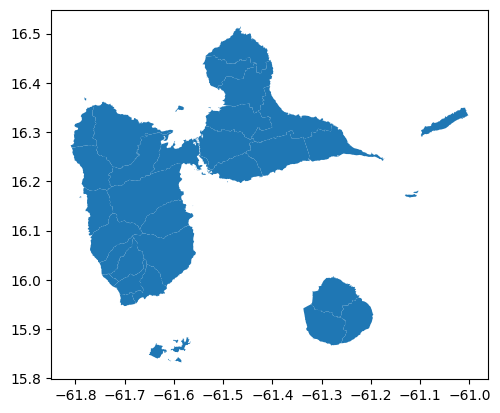

In [ ]:
import geopandas as gpd

query = "SELECT nom_commune_geojson, geography FROM `wagon-bootcamp-501621.risques_naturels.communes_geo` WHERE code_commune LIKE '971%'"
df = client.query(query).to_dataframe()
gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geography'].astype(str)))
gdf.plot()

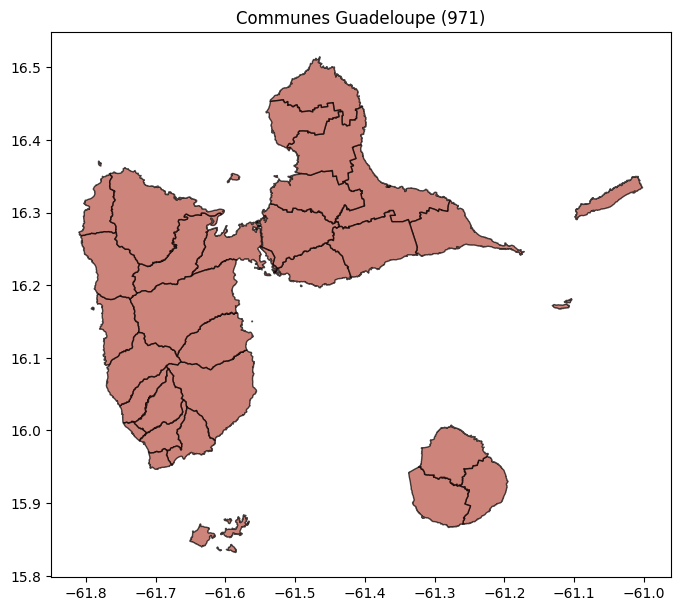

Nb de polygones affichés : 32
Emprise (bounding box) : [-61.809839  15.832041 -61.001959  16.514488]


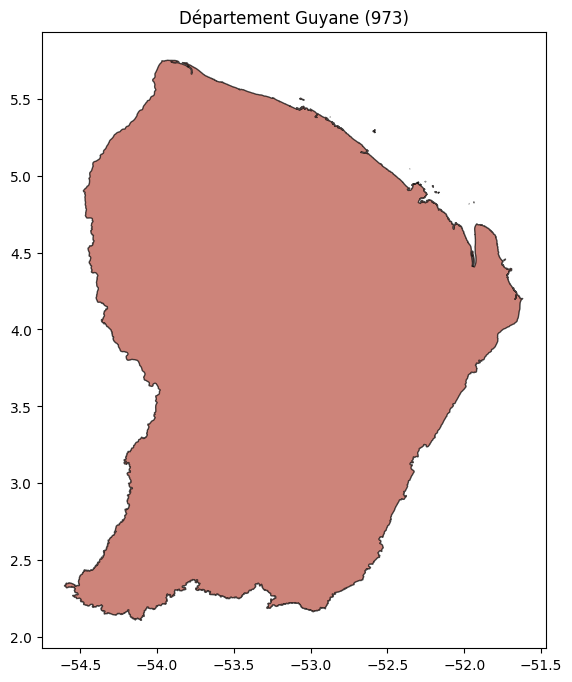

Nb de polygones affichés : 1
Emprise (bounding box) : [-54.602416   2.111073 -51.619066   5.748682]


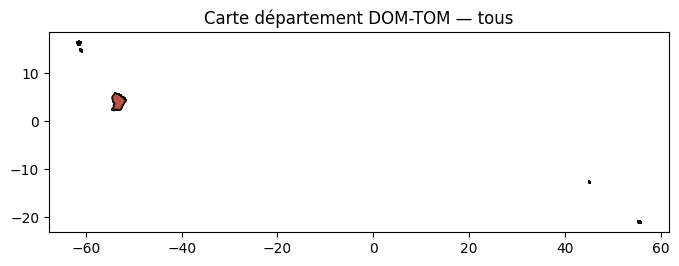

Nb de polygones affichés : 21
Emprise (bounding box) : [-61.809839 -21.389631  55.836654  16.514488]


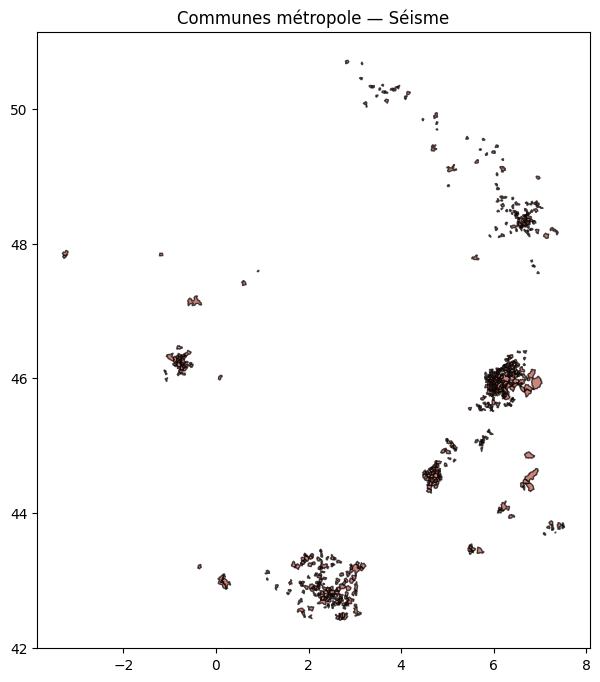

Nb de polygones affichés : 618
Emprise (bounding box) : [-3.31719565 42.40470428  7.53015938 50.72291764]


In [ ]:
!pip install geopandas --quiet

import geopandas as gpd
import matplotlib.pyplot as plt

def verifier_carte(nom_table, colonne_filtre=None, valeur_filtre=None, dataset="risques_naturels", titre=None):
    """
    Affiche rapidement les géométries d'une table/vue BigQuery pour vérifier
    visuellement qu'elles sont bonnes AVANT de les brancher dans Looker Studio.

    Exemples :
      verifier_carte("communes_geo", "code_commune", "971%")   # Guadeloupe
      verifier_carte("carte_catnat_departement_domtom")        # tout le contenu
      verifier_carte("carte_catnat_geo_metropole", "type_peril", "Séisme")
    """
    where_clause = ""
    if colonne_filtre and valeur_filtre:
        if "%" in valeur_filtre:
            where_clause = f"WHERE {colonne_filtre} LIKE '{valeur_filtre}'"
        else:
            where_clause = f"WHERE {colonne_filtre} = '{valeur_filtre}'"

    query = f"""
    SELECT *, ST_ASTEXT(geography) AS geography_wkt
    FROM `wagon-bootcamp-501621.{dataset}.{nom_table}`
    {where_clause}
    """
    df = client.query(query).to_dataframe()

    if df.empty:
        print(f"⚠️ Aucune ligne trouvée pour {nom_table} {where_clause}")
        return

    gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["geography_wkt"]), crs="EPSG:4326")

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf.plot(ax=ax, edgecolor="black", facecolor="#B85042", alpha=0.7)
    ax.set_title(titre or f"{nom_table} {where_clause}")
    plt.show()

    print(f"Nb de polygones affichés : {len(gdf)}")
    print(f"Emprise (bounding box) : {gdf.total_bounds}")


# ============================================================
# Exemples à lancer pour vérifier ce qu'on vient de créer
# ============================================================

# 1. Vérifier que les DOM-TOM sont bien dans communes_geo (Antilles)
verifier_carte("communes_geo", "code_commune", "971%", titre="Communes Guadeloupe (971)")

# 2. Vérifier departements_geo pour la Guyane
verifier_carte("departements_geo", "code_departement", "973", titre="Département Guyane (973)")

# 3. Vérifier toute la vue département DOM-TOM (celle qui posait souci de zoom sur Looker)
verifier_carte("carte_catnat_departement_domtom", titre="Carte département DOM-TOM — tous")

# 4. Vérifier un péril précis en métropole
verifier_carte("carte_catnat_geo_metropole", "type_peril", "Séisme", titre="Communes métropole — Séisme")

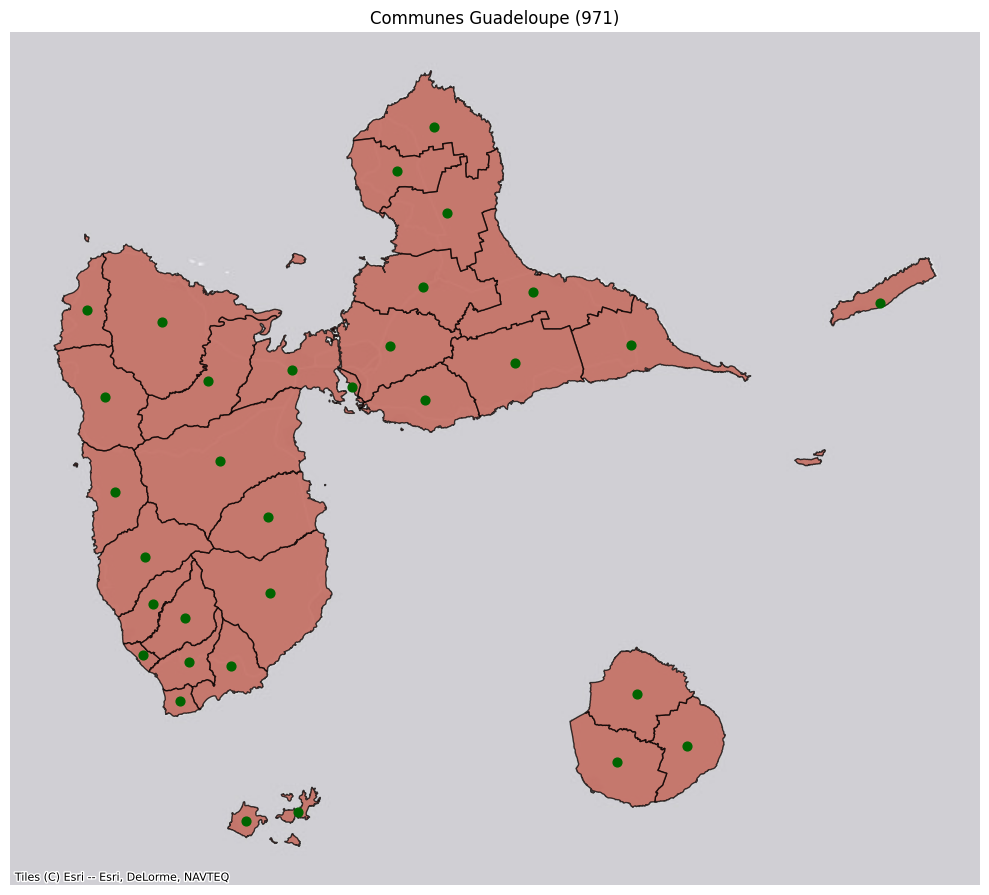

Nb de polygones affichés : 32
Emprise (bounding box, EPSG:4326) : [-61.809839  15.832041 -61.001959  16.514488]


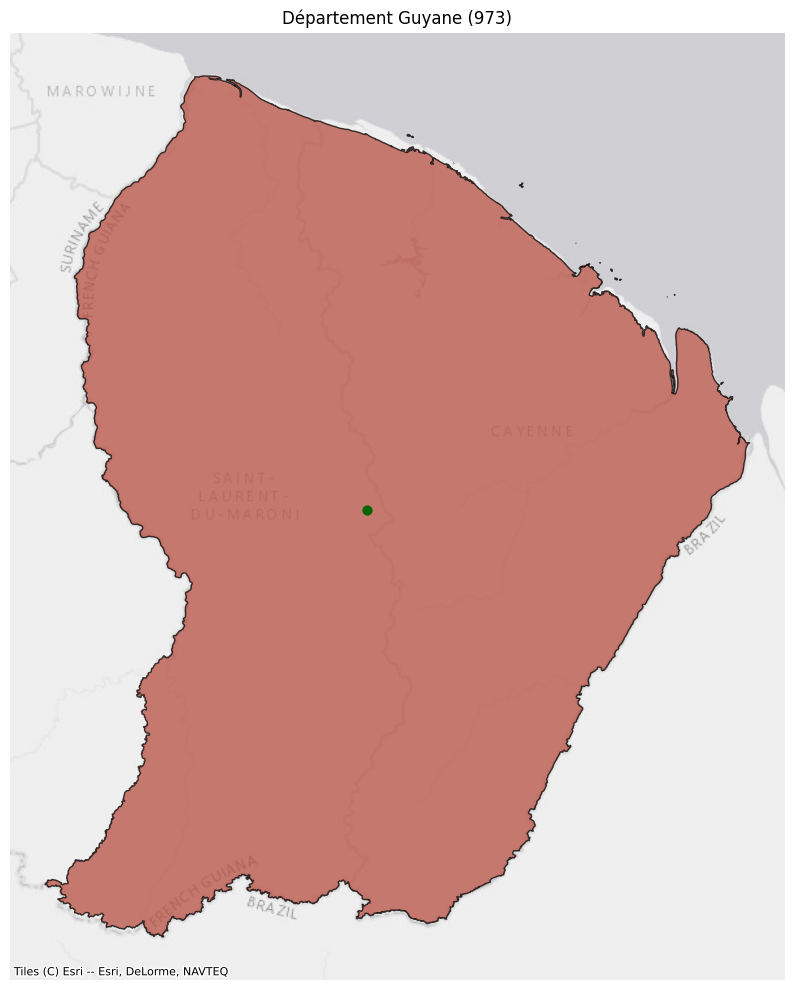

Nb de polygones affichés : 1
Emprise (bounding box, EPSG:4326) : [-54.602416   2.111073 -51.619066   5.748682]


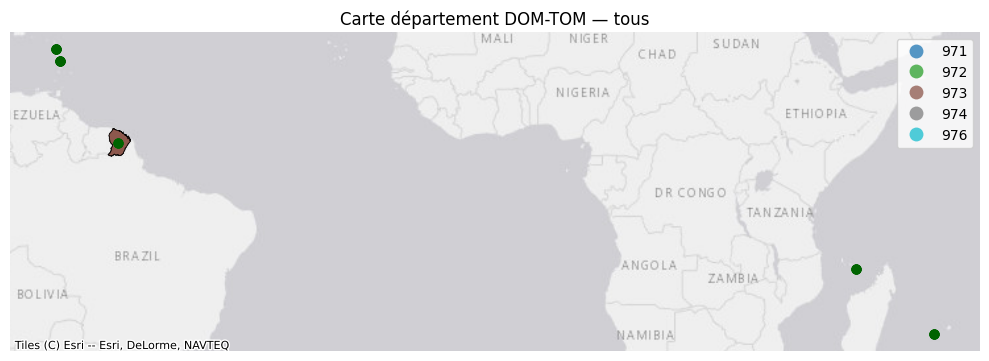

Nb de polygones affichés : 21
Emprise (bounding box, EPSG:4326) : [-61.809839 -21.389631  55.836654  16.514488]


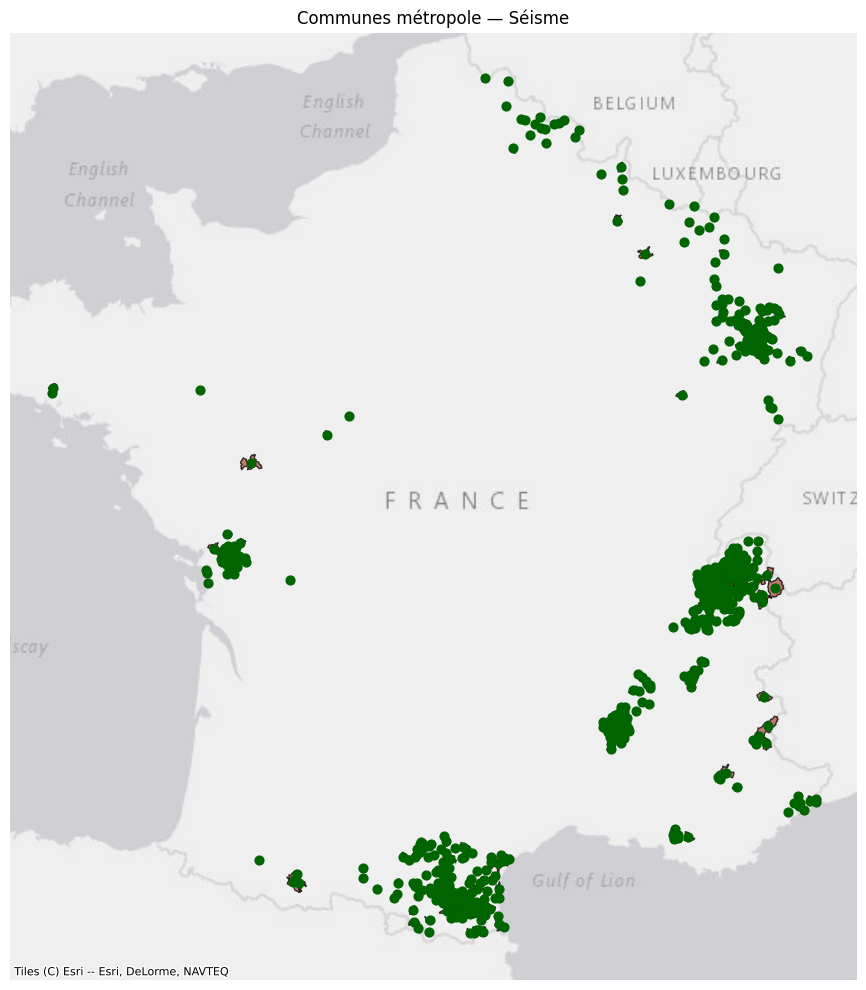

Nb de polygones affichés : 618
Emprise (bounding box, EPSG:4326) : [-3.31719565 42.40470428  7.53015938 50.72291764]


In [ ]:
!pip install geopandas contextily --quiet

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

def verifier_carte(nom_table, colonne_filtre=None, valeur_filtre=None, dataset="risques_naturels",
                    titre=None, colonne_couleur=None, afficher_centroides=True):
    """
    Affiche rapidement les géométries d'une table/vue BigQuery, avec un vrai
    fond de carte (rues/relief), pour vérifier visuellement AVANT de brancher
    dans Looker Studio.

    Exemples :
      verifier_carte("communes_geo", "code_commune", "971%", titre="Guadeloupe")
      verifier_carte("carte_catnat_departement_domtom", colonne_couleur="code_departement")
      verifier_carte("carte_catnat_geo_metropole", "type_peril", "Séisme")
    """
    where_clause = ""
    if colonne_filtre and valeur_filtre:
        if "%" in valeur_filtre:
            where_clause = f"WHERE {colonne_filtre} LIKE '{valeur_filtre}'"
        else:
            where_clause = f"WHERE {colonne_filtre} = '{valeur_filtre}'"

    query = f"""
    SELECT *, ST_ASTEXT(geography) AS geography_wkt
    FROM `wagon-bootcamp-501621.{dataset}.{nom_table}`
    {where_clause}
    """
    df = client.query(query).to_dataframe()

    if df.empty:
        print(f"⚠️ Aucune ligne trouvée pour {nom_table} {where_clause}")
        return

    gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["geography_wkt"]), crs="EPSG:4326")
    # contextily attend du Web Mercator (EPSG:3857), pas du lat/lon brut
    gdf_web = gdf.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(10, 10))

    if colonne_couleur and colonne_couleur in gdf_web.columns:
        gdf_web.plot(ax=ax, column=colonne_couleur, categorical=True, legend=True,
                     cmap="tab10", edgecolor="black", linewidth=0.5, alpha=0.75)
    else:
        gdf_web.plot(ax=ax, edgecolor="black", facecolor="#B85042", alpha=0.75)

    if afficher_centroides:
        centroides = gdf_web.geometry.centroid
        ax.scatter(centroides.x, centroides.y, color="darkgreen", s=40, zorder=5)

    # Ajoute le fond de carte (rues/relief) derrière les polygones
    # Esri (World Gray Canvas) : pas de clé API requise, tolère les appels
    # répétés en boucle (contrairement à OpenStreetMap/CartoDB, tous deux
    # bloqués car trop de requêtes automatisées d'affilée)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas)

    ax.set_axis_off()
    ax.set_title(titre or f"{nom_table} {where_clause}")
    plt.tight_layout()
    plt.show()

    print(f"Nb de polygones affichés : {len(gdf)}")
    print(f"Emprise (bounding box, EPSG:4326) : {gdf.total_bounds}")


# ============================================================
# Exemples à lancer pour vérifier ce qu'on vient de créer
# ============================================================

# 1. Vérifier que les DOM-TOM sont bien dans communes_geo (Antilles)
verifier_carte("communes_geo", "code_commune", "971%", titre="Communes Guadeloupe (971)")

# 2. Vérifier departements_geo pour la Guyane
verifier_carte("departements_geo", "code_departement", "973", titre="Département Guyane (973)")

# 3. Vérifier toute la vue département DOM-TOM, colorée par département
verifier_carte("carte_catnat_departement_domtom", colonne_couleur="code_departement",
               titre="Carte département DOM-TOM — tous")

# 4. Vérifier un péril précis en métropole
verifier_carte("carte_catnat_geo_metropole", "type_peril", "Séisme", titre="Communes métropole — Séisme")